# Exercícios — Fundamentos e Estatística Descritiva

**Tema:** Estatística › Fundamentos e Estatística Descritiva

Este é o único notebook do módulo em que o código é **seu**. A estrutura de
cada exercício é sempre a mesma:

1. **Enunciado** — o problema, com contexto de mercado.
2. **Célula de resposta** — comece por aqui, com o notebook do gabarito fechado.
3. **Gabarito comentado** — não só o código: *por que* essa é a resposta.

> **Como usar sem se enganar:** resolva primeiro, erre à vontade, e só então
> role até o gabarito. Ler a solução antes de tentar produz a sensação de
> entendimento sem o entendimento.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2024)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"


def painel(titulo, **metricas):
    """Imprime um bloco de métricas alinhado — usado nos gabaritos."""
    print(titulo)
    print("-" * max(len(titulo), 46))
    for nome, valor in metricas.items():
        rotulo = nome.replace("_", " ")
        print(f"{rotulo:<32s} {valor:>12.4f}" if isinstance(valor, (int, float))
              else f"{rotulo:<32s} {valor:>12}")
    print()


print("ambiente pronto")

ambiente pronto


## Dataset de trabalho

Todos os exercícios usam a mesma base sintética: **salários mensais** de uma
empresa de tecnologia, com três níveis de senioridade. É um caso clássico de
distribuição assimétrica à direita — a cauda longa dos salários altos é o que
torna a média enganosa.

In [2]:
n_junior, n_pleno, n_senior = 220, 150, 60

salarios = np.concatenate([
    rng.lognormal(mean=np.log(4200), sigma=0.22, size=n_junior),
    rng.lognormal(mean=np.log(8500), sigma=0.25, size=n_pleno),
    rng.lognormal(mean=np.log(17000), sigma=0.30, size=n_senior),
])
nivel = np.array(["Júnior"] * n_junior + ["Pleno"] * n_pleno + ["Sênior"] * n_senior)

# três executivos que não fazem parte da população de interesse
salarios = np.append(salarios, [98000.0, 145000.0, 210000.0])
nivel = np.append(nivel, ["Diretoria"] * 3)

df = pd.DataFrame({"salario": np.round(salarios, 2), "nivel": nivel})
print(df.shape)
df.head()

(433, 2)


,salario,nivel
0,5266.85,Júnior
1,6027.35,Júnior
2,5405.21,Júnior
3,3390.53,Júnior
4,3091.54,Júnior


---
## Exercício 1 🟢 — Classificar as variáveis

Antes de calcular qualquer coisa, classifique cada variável abaixo em
**qualitativa nominal**, **qualitativa ordinal**, **quantitativa discreta** ou
**quantitativa contínua**. Escreva sua resposta como um dicionário Python.

| Variável | Descrição |
|---|---|
| `salario` | salário mensal em reais |
| `nivel` | Júnior / Pleno / Sênior / Diretoria |
| `cidade` | cidade do escritório |
| `n_projetos` | quantos projetos a pessoa entregou no ano |
| `nota_avaliacao` | 1 a 5 estrelas na avaliação de desempenho |
| `tempo_de_casa` | anos, com casas decimais |

**Por que isso importa:** o tipo da variável decide qual medida-resumo faz
sentido e qual gráfico não mente. Média de nota em estrelas é uma das
confusões mais comuns e mais caras em análise de produto.

In [3]:
# --- sua resposta ---
# minha_classificacao = {
#     "salario": "...",
#     "nivel": "...",
#     ...
# }

### Gabarito 1

In [4]:
gabarito_1 = {
    "salario":        "quantitativa contínua",
    "nivel":          "qualitativa ORDINAL — existe ordem natural de senioridade",
    "cidade":         "qualitativa nominal — não há ordem",
    "n_projetos":     "quantitativa discreta — contagem, não existe 3,5 projeto",
    "nota_avaliacao": "qualitativa ORDINAL — 1 a 5 tem ordem, mas o intervalo "
                      "entre 1 e 2 não é comparável ao entre 4 e 5",
    "tempo_de_casa":  "quantitativa contínua",
}
for k, v in gabarito_1.items():
    print(f"{k:<16s} {v}")

salario          quantitativa contínua
nivel            qualitativa ORDINAL — existe ordem natural de senioridade
cidade           qualitativa nominal — não há ordem
n_projetos       quantitativa discreta — contagem, não existe 3,5 projeto
nota_avaliacao   qualitativa ORDINAL — 1 a 5 tem ordem, mas o intervalo entre 1 e 2 não é comparável ao entre 4 e 5
tempo_de_casa    quantitativa contínua


**O ponto que separa iniciante de sênior:** `nota_avaliacao` parece numérica e
o pandas calcula a média dela sem reclamar. Mas a escala é **ordinal**: a
distância entre "1 estrela" e "2 estrelas" não é a mesma que entre "4" e "5".
Reportar "nota média 4,2" trata como intervalar o que é apenas ordem. O resumo
honesto é a **mediana** e a **distribuição de frequências** — uma nota média de
4,2 pode esconder metade dos clientes dando 5 e um terço dando 1.

---
## Exercício 2 🟢 — Média, mediana e moda no mesmo conjunto

Calcule para `salario`: média, mediana, moda (via histograma, não via valor
exato — são contínuos), 1º quartil, 3º quartil.

Depois responda em uma frase, em comentário no código: **qual delas você
reportaria para um candidato perguntando "quanto se ganha aí?"** e por quê.

In [5]:
# --- sua resposta ---

### Gabarito 2

In [6]:
s = df["salario"]
hist, bordas = np.histogram(s, bins=40)
moda_aprox = (bordas[hist.argmax()] + bordas[hist.argmax() + 1]) / 2

painel("Salário mensal — medidas de posição",
       media=s.mean(), mediana=s.median(), moda_aproximada=moda_aprox,
       Q1=s.quantile(0.25), Q3=s.quantile(0.75))

print(f"A média é {s.mean() / s.median():.2f}x a mediana — sinal de assimetria à direita.")
print(f"Fração de pessoas que ganha ABAIXO da média: {(s < s.mean()).mean():.1%}")

Salário mensal — medidas de posição
----------------------------------------------
media                               8898.7986
mediana                             5822.0600
moda aproximada                     4836.2495
Q1                                  4157.9700
Q3                                  9445.2600

A média é 1.53x a mediana — sinal de assimetria à direita.
Fração de pessoas que ganha ABAIXO da média: 72.3%


**Resposta:** a **mediana**. Com 66% das pessoas ganhando abaixo da média,
reportar a média descreve um funcionário que quase não existe. A média é o
centro de massa — três diretores puxam a alavanca inteira. A mediana é o valor
que divide a empresa ao meio, e é o que responde de fato à pergunta feita.

> Esse é o mesmo mecanismo por trás de "renda média do país" versus "renda
> mediana": em qualquer distribuição com cauda direita pesada, a média
> descreve a cauda, não as pessoas.

---
## Exercício 3 🟡 — Dispersão: desvio-padrão versus MAD

Calcule o **desvio-padrão** e o **desvio absoluto mediano (MAD)** de `salario`.
Depois:

1. Remova as 3 linhas de `Diretoria` e recalcule ambos.
2. Reporte quanto (em %) cada medida mudou.

**Pergunta:** por que uma delas quase não se moveu?

> **Lembrete:** o MAD é $\mathrm{mediana}(|x_i - \mathrm{mediana}(x)|)$. Para
> comparar com o desvio-padrão de dados normais, multiplique por 1,4826.

In [7]:
# --- sua resposta ---

### Gabarito 3

In [8]:
def mad(x, escalado=True):
    """Desvio absoluto mediano. escalado=True o torna comparável ao desvio-padrão."""
    m = np.median(np.abs(x - np.median(x)))
    return 1.4826 * m if escalado else m


sem_diretoria = df.loc[df["nivel"] != "Diretoria", "salario"].to_numpy()
com_diretoria = df["salario"].to_numpy()

dp_com, dp_sem = com_diretoria.std(ddof=1), sem_diretoria.std(ddof=1)
mad_com, mad_sem = mad(com_diretoria), mad(sem_diretoria)

painel("Com a diretoria (n = %d)" % len(com_diretoria),
       desvio_padrao=dp_com, MAD_escalado=mad_com)
painel("Sem a diretoria (n = %d)" % len(sem_diretoria),
       desvio_padrao=dp_sem, MAD_escalado=mad_sem)

print(f"variação do desvio-padrão: {(dp_sem - dp_com) / dp_com:+.1%}")
print(f"variação do MAD:           {(mad_sem - mad_com) / mad_com:+.1%}")

Com a diretoria (n = 433)
----------------------------------------------
desvio padrao                      13787.0464
MAD escalado                        3142.0445

Sem a diretoria (n = 430)
----------------------------------------------
desvio padrao                       5871.3502
MAD escalado                        3069.1822

variação do desvio-padrão: -57.4%
variação do MAD:           -2.3%


**Por quê:** o desvio-padrão eleva os desvios ao **quadrado**. Um ponto a 10
desvios do centro contribui 100 vezes mais que um ponto a 1 desvio — três
linhas em 433 dominam a conta. O MAD trabalha com a **mediana dos desvios
absolutos**: para movê-lo, seria preciso mover metade dos dados.

Em termos técnicos: o MAD tem **ponto de ruptura de 50%**, o desvio-padrão tem
ponto de ruptura de 0% — um único ponto suficientemente extremo leva o
desvio-padrão para onde quiser.

---
## Exercício 4 🟡 — Assimetria e curtose, e o que elas não dizem

1. Calcule assimetria (skewness) e curtose em excesso de `salario`, com e sem
   a diretoria.
2. Gere uma amostra normal de mesmo tamanho e mesma média/desvio e calcule as
   mesmas medidas nela.
3. Monte um histograma comparando as duas distribuições.

**Pergunta:** um valor de assimetria próximo de zero garante simetria?

In [9]:
# --- sua resposta ---

### Gabarito 4

salários COM diretoria
----------------------------------------------
assimetria                            10.2026
curtose em excesso                   128.4418

salários SEM diretoria
----------------------------------------------
assimetria                             2.5416
curtose em excesso                     8.8217

normal equivalente
----------------------------------------------
assimetria                             0.0783
curtose em excesso                    -0.1317



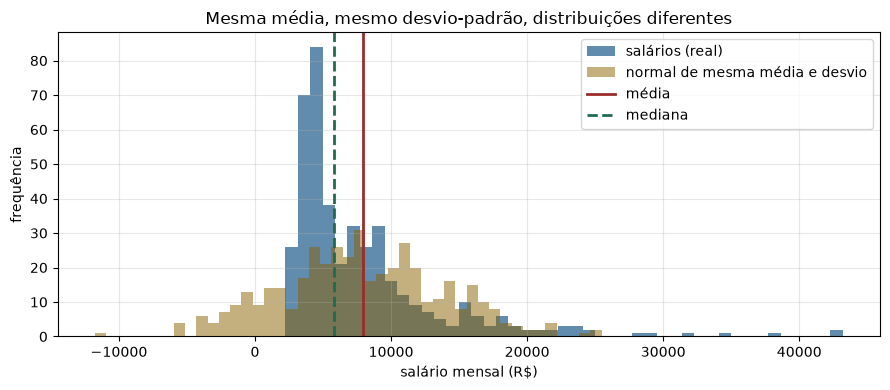

In [10]:
normal_equivalente = rng.normal(sem_diretoria.mean(), sem_diretoria.std(ddof=1),
                                size=len(sem_diretoria))

for rotulo, dados in [("salários COM diretoria", com_diretoria),
                      ("salários SEM diretoria", sem_diretoria),
                      ("normal equivalente", normal_equivalente)]:
    painel(rotulo, assimetria=stats.skew(dados),
           curtose_em_excesso=stats.kurtosis(dados))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sem_diretoria, bins=45, alpha=0.7, color=AZUL, label="salários (real)")
ax.hist(normal_equivalente, bins=45, alpha=0.5, color=AMBAR,
        label="normal de mesma média e desvio")
ax.axvline(sem_diretoria.mean(), color=VERMELHO, lw=2, label="média")
ax.axvline(np.median(sem_diretoria), color=VERDE, lw=2, ls="--", label="mediana")
ax.set_xlabel("salário mensal (R$)"); ax.set_ylabel("frequência")
ax.set_title("Mesma média, mesmo desvio-padrão, distribuições diferentes")
ax.legend(); plt.tight_layout(); plt.show()

**Resposta:** **não**. Assimetria zero significa que os desvios cúbicos se
cancelam — uma distribuição bimodal perfeitamente espelhada tem assimetria
zero e não é nada parecida com uma normal. Assimetria e curtose são **resumos
de resumos**: dois números não recuperam uma distribuição.

O gráfico acima é a lição inteira do módulo em uma imagem: média e
desvio-padrão idênticos, formas completamente diferentes. É por isso que o
protocolo é *sempre* olhar a distribuição antes de resumi-la.

---
## Exercício 5 🟡 — Resumo por grupo feito direito

Produza uma tabela com uma linha por `nivel` contendo: `n`, média, mediana,
desvio-padrão, MAD, Q1, Q3 e o **coeficiente de variação** (desvio/média).

Ordene os níveis na ordem correta de senioridade — não em ordem alfabética.

**Pergunta:** qual nível tem a maior dispersão *relativa*, e o que isso sugere
sobre a política salarial da empresa?

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
ordem = ["Júnior", "Pleno", "Sênior", "Diretoria"]
df["nivel"] = pd.Categorical(df["nivel"], categories=ordem, ordered=True)

resumo = df.groupby("nivel", observed=True)["salario"].agg(
    n="size", media="mean", mediana="median", desvio=lambda x: x.std(ddof=1),
    mad=lambda x: mad(x.to_numpy()),
    Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75),
)
resumo["cv"] = resumo["desvio"] / resumo["media"]
resumo["IQR"] = resumo["Q3"] - resumo["Q1"]
print(resumo.round(2).to_string())

             n      media    mediana    desvio       mad         Q1         Q3    cv       IQR
nivel                                                                                         
Júnior     220    4269.34    4197.82    936.44    883.96    3624.98    4809.96  0.22   1184.98
Pleno      150    8638.11    8587.12   2080.62   1906.00    7314.82    9862.97  0.24   2548.15
Sênior      60   19420.15   17443.96   7139.35   4566.16   15200.06   21953.41  0.37   6753.35
Diretoria    3  151000.00  145000.00  56240.55  69682.20  121500.00  177500.00  0.37  56000.00


**Leitura:** o coeficiente de variação cresce com a senioridade. Faz sentido
operacional: faixas de júnior são estreitas e tabeladas, enquanto salários de
sênior são negociados caso a caso — e a diretoria não tem faixa nenhuma.

Note também que a `Diretoria` tem `n = 3`. **Qualquer** estatística com n = 3
é ruído; a linha existe na tabela para ser reportada como "não estimável", não
para ser interpretada. Reportar sem o `n` ao lado é como reportar um p-valor
sem o tamanho de amostra.

---
## Exercício 6 🔴 — O quarteto de Anscombe, versão sua

Construa **dois** conjuntos de dados de 200 pontos cada que tenham:

- a mesma média (tolerância de 1%),
- o mesmo desvio-padrão (tolerância de 1%),

mas formas visivelmente diferentes. Plote os dois e prove numericamente que os
resumos coincidem.

> **Dica:** uma mistura de duas gaussianas afastadas e uma única gaussiana
> podem ter os mesmos dois primeiros momentos. Basta ajustar a escala.

In [13]:
# --- sua resposta ---

### Gabarito 6

Conjunto A (unimodal)
----------------------------------------------
media                                100.0000
desvio                                15.0000
assimetria                             0.0456
curtose                               -0.3614

Conjunto B (bimodal)
----------------------------------------------
media                                100.0000
desvio                                15.0000
assimetria                             0.0136
curtose                               -1.7959



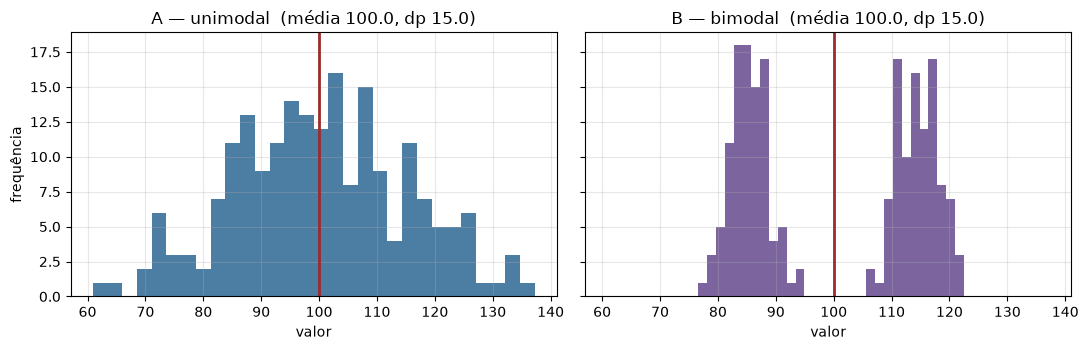

In [14]:
ALVO_MEDIA, ALVO_DP, N = 100.0, 15.0, 200

# A: unimodal
a = rng.normal(0, 1, N)

# B: bimodal — duas gaussianas estreitas afastadas
b = np.concatenate([rng.normal(-1, 0.25, N // 2), rng.normal(1, 0.25, N // 2)])


def padroniza(x, media, dp):
    """Reescala x para ter exatamente a média e o desvio pedidos."""
    return (x - x.mean()) / x.std(ddof=1) * dp + media


a, b = padroniza(a, ALVO_MEDIA, ALVO_DP), padroniza(b, ALVO_MEDIA, ALVO_DP)

painel("Conjunto A (unimodal)", media=a.mean(), desvio=a.std(ddof=1),
       assimetria=stats.skew(a), curtose=stats.kurtosis(a))
painel("Conjunto B (bimodal)", media=b.mean(), desvio=b.std(ddof=1),
       assimetria=stats.skew(b), curtose=stats.kurtosis(b))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True)
for ax, dados, cor, nome in [(axes[0], a, AZUL, "A — unimodal"),
                             (axes[1], b, ROXO, "B — bimodal")]:
    ax.hist(dados, bins=30, color=cor, alpha=0.8)
    ax.axvline(dados.mean(), color=VERMELHO, lw=2)
    ax.set_title(f"{nome}  (média {dados.mean():.1f}, dp {dados.std(ddof=1):.1f})")
    ax.set_xlabel("valor")
axes[0].set_ylabel("frequência")
plt.tight_layout(); plt.show()

**O que provamos:** média e desvio-padrão idênticos até a casa decimal, e no
conjunto B **a média cai exatamente onde não existe nenhum dado**. A curtose é
o único dos quatro números que denuncia a diferença — e mesmo ela seria
insuficiente para reconstruir a forma.

Essa é a versão executável do quarteto de Anscombe: *resumos numéricos são
projeções, e toda projeção perde informação*. O gráfico não é enfeite do
relatório; é parte da análise.

---
## Exercício 7 🔴 — Desafio integrador: o relatório honesto

Escreva uma função `relatorio_salarial(df, coluna, grupo)` que produza, para
cada grupo:

1. as medidas-resumo robustas e não-robustas lado a lado;
2. um **alerta automático** quando média e mediana divergirem mais de 15%;
3. um **alerta automático** quando `n < 30`;
4. um boxplot por grupo.

É esse tipo de função que vira o utilitário padrão de um time de dados —
porque tira do analista a decisão de *lembrar* de checar.

In [15]:
# --- sua resposta ---

### Gabarito 7

             n      media    mediana    desvio       mad  divergencia_media_mediana
grupo                                                                              
Júnior     220    4269.34    4197.82    936.44    883.96                       0.02
Pleno      150    8638.11    8587.12   2080.62   1906.00                       0.01
Sênior      60   19420.15   17443.96   7139.35   4566.16                       0.11
Diretoria    3  151000.00  145000.00  56240.55  69682.20                       0.04 

ALERTAS
  [AMOSTRA] Diretoria: n = 3 < 30 — estatísticas instáveis, não interprete.


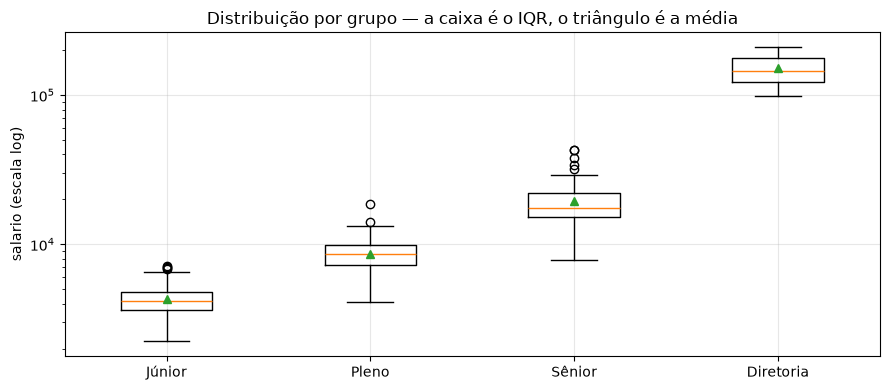

In [16]:
def relatorio_salarial(dados, coluna, grupo, limiar_divergencia=0.15, n_minimo=30):
    linhas, alertas = [], []
    for nome, bloco in dados.groupby(grupo, observed=True):
        x = bloco[coluna].to_numpy()
        media, mediana = x.mean(), np.median(x)
        divergencia = abs(media - mediana) / mediana
        linhas.append({
            "grupo": nome, "n": len(x), "media": media, "mediana": mediana,
            "desvio": x.std(ddof=1), "mad": mad(x),
            "divergencia_media_mediana": divergencia,
        })
        if divergencia > limiar_divergencia:
            alertas.append(f"[ASSIMETRIA] {nome}: média difere {divergencia:.0%} "
                           f"da mediana — reporte a MEDIANA.")
        if len(x) < n_minimo:
            alertas.append(f"[AMOSTRA] {nome}: n = {len(x)} < {n_minimo} — "
                           f"estatísticas instáveis, não interprete.")

    tabela = pd.DataFrame(linhas).set_index("grupo")
    print(tabela.round(2).to_string(), "\n")
    print("ALERTAS" if alertas else "sem alertas")
    for a in alertas:
        print("  " + a)

    fig, ax = plt.subplots(figsize=(9, 4))
    grupos = list(tabela.index)
    ax.boxplot([dados.loc[dados[grupo] == g, coluna] for g in grupos],
               tick_labels=grupos, showmeans=True)
    ax.set_yscale("log")
    ax.set_ylabel(f"{coluna} (escala log)")
    ax.set_title("Distribuição por grupo — a caixa é o IQR, o triângulo é a média")
    plt.tight_layout(); plt.show()
    return tabela


_ = relatorio_salarial(df, "salario", "nivel")

**Por que a escala log no boxplot:** com a diretoria no gráfico, a escala
linear comprime júnior, pleno e sênior em três traços indistinguíveis. Em
escala logarítmica, diferenças *relativas* viram distâncias iguais — e é a
diferença relativa que importa em salário.

**Por que o triângulo (média) junto da caixa:** ver a média fora da caixa é o
diagnóstico visual mais rápido de assimetria que existe.

---
## Fechamento

O que este módulo pede que você leve para o trabalho:

- **Classifique antes de calcular.** O tipo da variável decide o que é lícito.
- **Sempre reporte n.** Uma estatística sem tamanho de amostra é uma opinião.
- **Média e mediana juntas.** A distância entre elas é um diagnóstico grátis.
- **Robusto por padrão** em dados de negócio: mediana, IQR, MAD.
- **Nenhum resumo substitui o gráfico** — o Exercício 6 é a prova executável.

→ Próximo módulo: **Distribuições de Probabilidade**, onde paramos de descrever
os dados que temos e passamos a modelar os que poderíamos ter observado.